In [3]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora, models


/Users/alisha/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/var/folders/d9/sbfhfygx5vx9mlfxxhcxrb280000gn/T/ipykernel_81195/2008873228.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [22]:
# Assuming the CSV file has a column named 'dialogue' containing the dialogues
df = pd.read_csv('is_this_it.csv').dropna()
df

,[Music]
1,[Applause]
3,[Music]
5,[Applause]
7,what
9,[Music]
...,...
5237,mind I try to be open
5239,me for every that I cry I will try to
5241,Dre the around every I want to keep the
5243,pain


In [23]:
# Assuming the dialogues are in the first column (index 0)
dialogues = df.iloc[:, 0]

In [24]:
# Preprocess the text
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alisha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/alisha/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/alisha/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [25]:
df

,[Music]
1,[Applause]
3,[Music]
5,[Applause]
7,what
9,[Music]
...,...
5237,mind I try to be open
5239,me for every that I cry I will try to
5241,Dre the around every I want to keep the
5243,pain


In [27]:
# Load the regular expression library
import re
# Remove punctuation
df['paper_text_processed'] = \
df.map(lambda x: re.sub('[,\.!?]', '', x))
# Convert the titles to lowercase
df['paper_text_processed'] = \
df['paper_text_processed'].map(lambda x: x.lower())
# Print out the first rows of papers
df['paper_text_processed']

1                                    [applause]
3                                       [music]
5                                    [applause]
7                                          what
9                                       [music]
                         ...                   
5237                      mind i try to be open
5239      me for every that i cry i will try to
5241    dre the around every i want to keep the
5243                                       pain
5245                                     inside
Name: paper_text_processed, Length: 2620, dtype: object

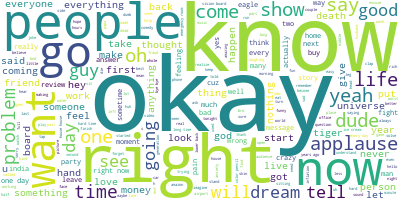

In [28]:
# Import the wordcloud library
from wordcloud import WordCloud
# Join the different processed titles together.
long_string = ','.join(list(df['paper_text_processed'].values))
# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=700, contour_width=3, contour_color='steelblue')
# Generate a word cloud
wordcloud.generate(long_string)
# Visualize the word cloud
wordcloud.to_image()

In [63]:
import gensim
from gensim.utils import simple_preprocess
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use', 'one', 'say', 'want', 'yeah', 'know', 'says', 'said', 'come', 'take', 'hey', 'came', 'like', 'would', 'need', 'go', 'okay', 'get', 'someone', 'applause', 'also', 'oh', 'bye', 'anything', 'dude', 'people', 'something'])
def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) 
             if word not in stop_words] for doc in texts]
data = df.paper_text_processed.values.tolist()
data_words = list(sent_to_words(data))
# remove stop words
data_words = remove_stopwords(data_words)
print(data_words[:1][0][:30])

[]


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alisha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


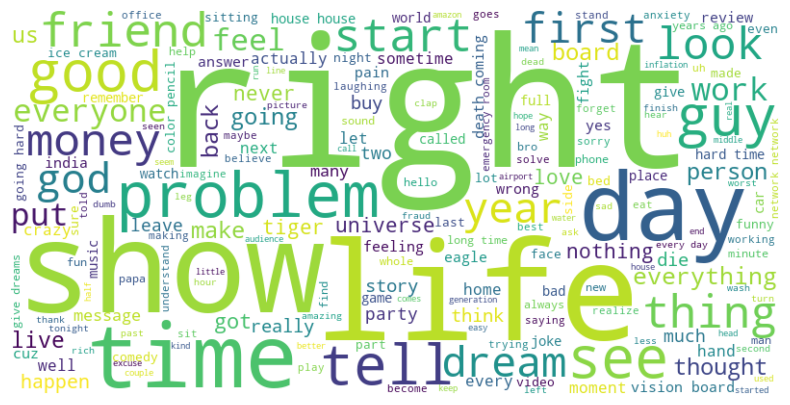

In [64]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert list of lists to a single string
long_string = ' '.join([' '.join(words) for words in data_words])

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(long_string)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [65]:
import gensim
from gensim.utils import simple_preprocess
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])
def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) 
             if word not in stop_words] for doc in texts]
# data = data_words.values.tolist()
# data_words = list(sent_to_words(data))
# remove stop words
data_words = remove_stopwords(data_words)
print(data_words[:1][0][:30])

[]


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alisha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [66]:
import gensim.corpora as corpora
# Create Dictionary
id2word = corpora.Dictionary(data_words)
# Create Corpus
texts = data_words
# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]
# View
print(corpus[:1][0][:30])

[]


In [67]:
from pprint import pprint
# number of topics
num_topics = 10
# Build LDA model
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=id2word,
                                       num_topics=num_topics)
# Print the Keyword in the 10 topics
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.027*"life" + 0.012*"back" + 0.011*"house" + 0.010*"every" + 0.009*"going" '
  '+ 0.009*"money" + 0.007*"welcome" + 0.007*"right" + 0.007*"network" + '
  '0.007*"everything"'),
 (1,
  '0.020*"everyone" + 0.013*"see" + 0.013*"tell" + 0.012*"got" + 0.011*"life" '
  '+ 0.009*"sure" + 0.008*"around" + 0.008*"guys" + 0.008*"give" + '
  '0.007*"start"'),
 (2,
  '0.027*"time" + 0.014*"dreams" + 0.010*"things" + 0.010*"love" + '
  '0.009*"good" + 0.009*"look" + 0.008*"give" + 0.008*"death" + 0.008*"part" + '
  '0.006*"going"'),
 (3,
  '0.019*"right" + 0.014*"put" + 0.013*"board" + 0.013*"nothing" + '
  '0.011*"problem" + 0.010*"hard" + 0.010*"see" + 0.009*"show" + 0.009*"feel" '
  '+ 0.007*"message"'),
 (4,
  '0.014*"years" + 0.011*"wrong" + 0.010*"good" + 0.009*"house" + 0.008*"make" '
  '+ 0.008*"play" + 0.008*"second" + 0.008*"party" + 0.008*"board" + '
  '0.008*"friend"'),
 (5,
  '0.027*"right" + 0.026*"show" + 0.011*"let" + 0.009*"thought" + 0.008*"guru" '
  '+ 0.008*"much" + 0.0


Coherence Score: 0.6908286487890681


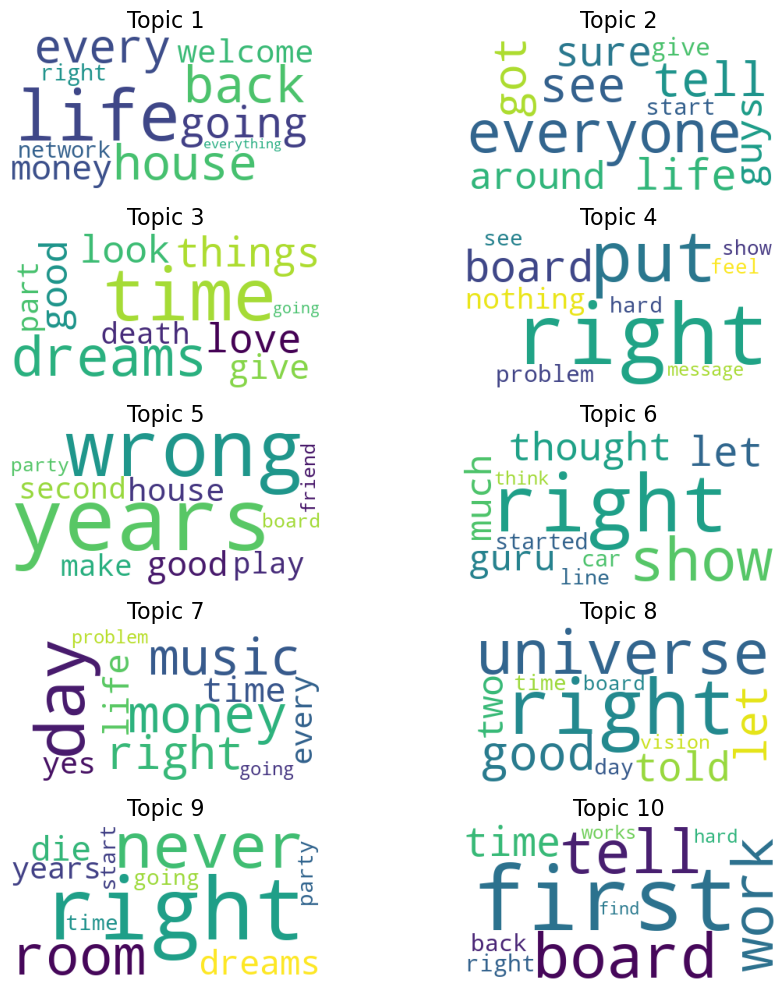

In [68]:
import matplotlib.pyplot as plt
from gensim.models import CoherenceModel

# Compute coherence score
coherence_model_lda = CoherenceModel(model=lda_model, texts=data_words, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score:', coherence_lda)

# Visualize topics
topics = lda_model.show_topics(formatted=False)

# Plotting
fig, axes = plt.subplots(num_topics // 2, 2, figsize=(10,10), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    fig.add_subplot(ax)
    topic_words = dict(topics[i][1])
    cloud = WordCloud(background_color='white').generate_from_frequencies(topic_words)
    plt.gca().imshow(cloud)
    plt.gca().set_title('Topic ' + str(i+1), fontdict=dict(size=16))
    plt.gca().axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.axis('off')
plt.margins(x=0, y=0)
plt.tight_layout()
plt.show()
